# Used Cars — Craigslist
### Limpieza, análisis exploratorio y preparación de datos

---
Dataset: [Craigslist Cars and Trucks — Kaggle](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 25)

---
## 1. Carga del dataset

### Origen
Dataset scrapeado de **Craigslist**, el sitio de clasificados más grande de Estados Unidos. Publicado en Kaggle por *austinreese*.

### Problema que aborda
Predecir el **precio de un automóvil usado** a partir de características como fabricante, modelo, año, kilometraje, condición y tipo de combustible.

### Justificación de la elección
- Contiene suciedad real: precios imposibles, nulos en columnas clave, valores inconsistentes en categóricas.
- Mezcla de variables numéricas y categóricas que requieren transformaciones concretas.
- Gran volumen de datos (426k filas) que representa un caso realista de preprocesamiento.


In [ ]:

datos = pd.read_csv(r"C:\Users\joel_\Downloads\used_cars_dataset\data\dataset.csv", encoding="latin-1")

print(f"Shape: {datos.shape}")

pd.set_option("display.max_columns", 25)


ModuleNotFoundError: No module named 'google.colab'

---
## 2. Análisis Exploratorio Inicial (EDA)


### 2.1 Vista general

In [ ]:
datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [ ]:
datos.describe()


,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [ ]:
datos.describe(include="object")


,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
count,426880,426880,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426812,426810,426880,426812
unique,426880,404,413,42,29667,6,8,5,6,3,118264,3,4,13,12,241899,360911,51,381536
top,https://wyoming.craigslist.org/ctd/d/atlanta-2...,columbus,https://spokane.craigslist.org,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,ca,2021-04-23T22:13:05-0400
freq,1,3608,2988,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,7357,231,50614,12


### 2.2 Valores nulos

In [ ]:
cantidad_nulos = datos.isnull().sum()
porcentaje_nulos = (cantidad_nulos / len(datos) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "nulos": cantidad_nulos,
    "porcentaje": porcentaje_nulos
}).sort_values("nulos", ascending=False)

print(resumen_nulos[resumen_nulos["nulos"] > 0])


               nulos  porcentaje
county        426880      100.00
size          306361       71.77
cylinders     177678       41.62
condition     174104       40.79
VIN           161042       37.73
drive         130567       30.59
paint_color   130203       30.50
type           92858       21.75
manufacturer   17646        4.13
title_status    8242        1.93
lat             6549        1.53
long            6549        1.53
model           5277        1.24
odometer        4400        1.03
fuel            3013        0.71
transmission    2556        0.60
year            1205        0.28
description       70        0.02
posting_date      68        0.02
image_url         68        0.02


De acá ya podemos sacar algunas conclusiones:
- `county` tiene el 100% de nulos, se elimina directamente.
- `size`, `cylinders`, `condition`, `drive` y `paint_color` tienen entre 30% y 70% de nulos, hay que decidir si imputar o eliminar.
- `VIN`, `url`, `region_url`, `image_url`, `description` no aportan información útil para el modelo.


### 2.3 Análisis del target (price)

In [ ]:
print("Estadisticas del precio:")
print(datos["price"].describe())
print()
print(f"Precios = 0:         {(datos['price'] == 0).sum()}")
print(f"Precios > 100.000:   {(datos['price'] > 100000).sum()}")
print(f"Precios > 1.000.000: {(datos['price'] > 1000000).sum()}")


Estadisticas del precio:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Precios = 0:         32895
Precios > 100.000:   655
Precios > 1.000.000: 53


### 2.4 Distribución de variables numéricas

In [ ]:
print("Año:")
print(datos["year"].describe())
print()
print("Odometro:")
print(datos["odometer"].describe())


Año:
count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

Odometro:
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64


### 2.5 Distribución de variables categóricas

In [ ]:
columnas_categoricas = ["manufacturer", "condition", "fuel", "transmission", "type", "title_status", "drive"]

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(datos[columna].value_counts().head(10))



manufacturer:
manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
jeep         19014
ram          18342
gmc          16785
bmw          14699
dodge        13707
Name: count, dtype: int64

condition:
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

fuel:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

transmission:
transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64

type:
type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
Name: count, dtype: int64

title_status:
title_status
clean         405117
rebuilt         7219
salvage         3868
li

---
## 3. Limpieza de datos


### 3.1 Eliminación de columnas irrelevantes

In [ ]:
# Columnas que no aportan información útil para predecir precio
columnas_a_eliminar = [
    "id",           # identificador interno
    "url",          # url del anuncio
    "region_url",   # url de la region
    "image_url",    # url de la imagen
    "description",  # texto libre sin estructura
    "VIN",          # numero de chasis, no predictivo
    "county",       # 100% nulos
    "lat",          # coordenadas geograficas, no relevantes para precio
    "long",
    "posting_date", # fecha del anuncio, no del auto
    "region",       # demasiados valores unicos (404), state lo resume mejor
]

datos.drop(columns=columnas_a_eliminar, inplace=True)
print(f"Shape despues de eliminar columnas: {datos.shape}")
print(f"Columnas restantes: {datos.columns.tolist()}")


Shape despues de eliminar columnas: (426880, 15)
Columnas restantes: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


### 3.2 Corrección de tipos de datos

In [ ]:
print("Tipos de datos actuales:")
print(datos.dtypes)


Tipos de datos actuales:
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
size             object
type             object
paint_color      object
state            object
dtype: object


In [ ]:
# year debe ser entero, viene como float por los nulos
datos["year"] = pd.to_numeric(datos["year"], errors="coerce")

# odometer debe ser entero
datos["odometer"] = pd.to_numeric(datos["odometer"], errors="coerce")

print("Tipos corregidos:")
print(datos[["year", "odometer", "price"]].dtypes)


Tipos corregidos:
year        float64
odometer    float64
price         int64
dtype: object


##Acotacion :

Digo que voy a convertir los tipos de datos a INT usando pd.to_numeric, pero sigue diciendo float porque pd.to_numeric solo convierte los valores a numérico sin forzar el tipo a entero. Como todavía pueden existir nulos en esas columnas, pandas los mantiene como float64 — un entero no puede representar NaN. El .astype(int) se aplica más adelante, una vez finalizada la imputación de nulos.


### 3.3 Outliers en precio, año y odómetro

In [ ]:
filas_antes = datos.shape[0]

# Filtrar precios fuera de rango razonable para autos usados
datos = datos[(datos["price"] >= 500) & (datos["price"] <= 100000)]

# Filtrar años imposibles
datos = datos[(datos["year"] >= 1980) & (datos["year"] <= 2023)]

# Filtrar odometro imposible
datos = datos[datos["odometer"] <= 500000]

filas_despues = datos.shape[0]
eliminadas = filas_antes - filas_despues

print(f"Filas antes:   {filas_antes}")
print(f"Filas despues: {filas_despues}")
print(f"Eliminadas:    {eliminadas} ({eliminadas / filas_antes * 100:.1f}%)")


Filas antes:   426880
Filas despues: 372094
Eliminadas:    54786 (12.8%)


### 3.4 Inconsistencias en variables categóricas

In [ ]:
# Normalizar: minusculas y sin espacios extra
cols_texto = datos.select_dtypes(include="object").columns.tolist()

for columna in cols_texto:
    datos[columna] = datos[columna].astype(str).str.strip().str.lower()
    datos[columna] = datos[columna].replace(["nan", "other", "unknown", ""], np.nan)

print("Normalizacion completada")
print()
print("Nulos despues de normalizacion:")
print(datos[cols_texto].isnull().sum().sort_values(ascending=False))


Normalizacion completada

Nulos despues de normalizacion:
size            268091
cylinders       153635
condition       140801
drive           112715
paint_color     107001
type             97870
transmission     61936
fuel             29278
manufacturer     12244
title_status      6487
model             3638
state                0
dtype: int64


### 3.5 Tratamiento de valores nulos

In [ ]:
# Columnas con muchos nulos
cols_con_nulos = ["size", "cylinders", "condition", "drive", "paint_color"]

print("Porcentaje de nulos en columnas problematicas:")
for columna in cols_con_nulos:
    porcentaje = datos[columna].isnull().sum() / len(datos) * 100
    print(f"  {columna}: {porcentaje:.1f}%")


Porcentaje de nulos en columnas problematicas:
  size: 72.0%
  cylinders: 41.3%
  condition: 37.8%
  drive: 30.3%
  paint_color: 28.8%


In [ ]:
# Columnas con mas del 40% de nulos se eliminan, el resto se imputa con la moda
umbral = 40

cols_eliminar = []
cols_imputar = []

for columna in cols_con_nulos:
    porcentaje = datos[columna].isnull().sum() / len(datos) * 100
    if porcentaje > umbral:
        cols_eliminar.append(columna)
    else:
        cols_imputar.append(columna)

print(f"Columnas a eliminar (> {umbral}% nulos): {cols_eliminar}")
print(f"Columnas a imputar: {cols_imputar}")

datos.drop(columns=cols_eliminar, inplace=True)

for columna in cols_imputar:
    moda = datos[columna].mode()[0]
    datos[columna].fillna(moda, inplace=True)
    print(f"  {columna}: imputado con '{moda}'")


Columnas a eliminar (> 40% nulos): ['size', 'cylinders']
Columnas a imputar: ['condition', 'drive', 'paint_color']
  condition: imputado con 'good'
  drive: imputado con '4wd'
  paint_color: imputado con 'white'


/tmp/ipykernel_16866/1568690231.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos[columna].fillna(moda, inplace=True)


In [ ]:
# Imputar nulos restantes
for columna in datos.columns:
    cantidad = datos[columna].isnull().sum()
    if cantidad == 0:
        continue
    if datos[columna].dtype == "object":
        moda = datos[columna].mode()[0]
        datos[columna].fillna(moda, inplace=True)
        print(f"  {columna}: imputado con moda = '{moda}'")
    else:
        mediana = datos[columna].median()
        datos[columna].fillna(mediana, inplace=True)
        print(f"  {columna}: imputado con mediana = {mediana}")

print(f"\nNulos restantes: {datos.isnull().sum().sum()}")


  manufacturer: imputado con moda = 'ford'


/tmp/ipykernel_16866/1860265851.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos[columna].fillna(moda, inplace=True)


  model: imputado con moda = 'f-150'
  fuel: imputado con moda = 'gas'
  title_status: imputado con moda = 'clean'
  transmission: imputado con moda = 'automatic'
  type: imputado con moda = 'sedan'

Nulos restantes: 0


In [ ]:
# una vez que no hay mas nulos, convierto a entero
datos["year"] = datos["year"].astype(int)
datos["odometer"] = datos["odometer"].astype(int)

print(datos[["year", "odometer", "price"]].dtypes)

year        int64
odometer    int64
price       int64
dtype: object


### 3.6 Duplicados

In [ ]:
duplicados = datos.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")

datos.drop_duplicates(inplace=True)
print(f"Shape final: {datos.shape}")


Duplicados encontrados: 109768
Shape final: (262326, 13)


---
## 4. Selección de variables y transformaciones


### 4.1 Selección de variables

In [ ]:
print("Columnas disponibles:")
print(datos.columns.tolist())


Columnas disponibles:
['price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


In [ ]:
variables_numericas = ["year", "odometer"]
variables_categoricas = ["manufacturer", "fuel", "transmission", "type", "title_status", "state"]
variable_objetivo = "price"

# Justificacion:
# year: la antiguedad del auto tiene impacto directo en el precio
# odometer: a mayor kilometraje, menor precio
# manufacturer: la marca influye mucho en el valor de mercado
# fuel: el tipo de combustible afecta la demanda y precio
# transmission: automatico vs manual tiene diferencia de precio
# type: sedan, SUV, pickup tienen rangos de precio muy distintos
# title_status: si el titulo esta limpio o tiene salvage baja mucho el precio
# state: el mercado varia segun el estado de EE.UU.

# Variables descartadas:
# model: demasiados valores unicos (29k+), necesitaria procesamiento especial
# condition/drive: eliminadas por alto porcentaje de nulos

variables = variables_numericas + variables_categoricas
print(f"Variables seleccionadas: {variables}")
print(f"Variable objetivo: {variable_objetivo}")

datos_modelo = datos[variables + [variable_objetivo]].copy()
print(f"\nShape del dataset para modelado: {datos_modelo.shape}")


Variables seleccionadas: ['year', 'odometer', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'state']
Variable objetivo: price

Shape del dataset para modelado: (262326, 9)


### 4.2 Codificación de variables categóricas

In [ ]:
codificador = LabelEncoder()

for columna in variables_categoricas:
    datos_modelo[columna] = codificador.fit_transform(datos_modelo[columna].astype(str))
    print(f"  {columna}: {datos[columna].nunique()} categorias codificadas")

print("\nEncoding completado.")


  manufacturer: 42 categorias codificadas
  fuel: 4 categorias codificadas
  transmission: 2 categorias codificadas
  type: 12 categorias codificadas
  title_status: 6 categorias codificadas
  state: 51 categorias codificadas

Encoding completado.


### 4.3 Escalado de variables numéricas

In [ ]:
escalador = StandardScaler()
datos_modelo[variables_numericas] = escalador.fit_transform(datos_modelo[variables_numericas])

print("Variables escaladas:", variables_numericas)
print()
datos_modelo[variables_numericas].describe().round(3)


Variables escaladas: ['year', 'odometer']



,year,odometer
count,262326.000,262326.000
mean,-0.000,-0.000
std,1.000,1.000
min,-4.621,-1.505
25%,-0.637,-0.849
50%,0.248,-0.068
75%,0.838,0.659
max,1.576,6.126


### 4.4 Visualización de variables seleccionadas

Correlacion con precio:
year            0.545
odometer        0.528
fuel            0.267
title_status    0.087
transmission    0.077
manufacturer    0.052
state           0.012
type            0.008
Name: price, dtype: float64


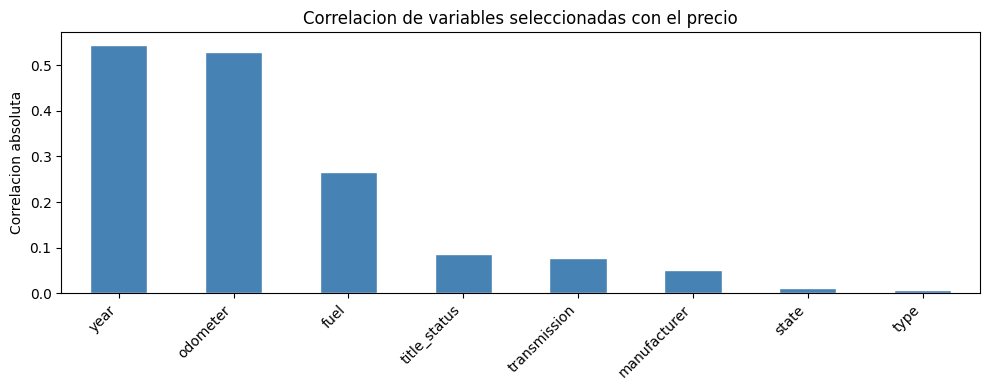

In [ ]:
correlacion_con_precio = datos_modelo.corr()["price"].drop("price").abs().sort_values(ascending=False)

print("Correlacion con precio:")
print(correlacion_con_precio.round(3))

correlacion_con_precio.plot(kind="bar", figsize=(10, 4), color="steelblue", edgecolor="white")
plt.title("Correlacion de variables seleccionadas con el precio")
plt.ylabel("Correlacion absoluta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


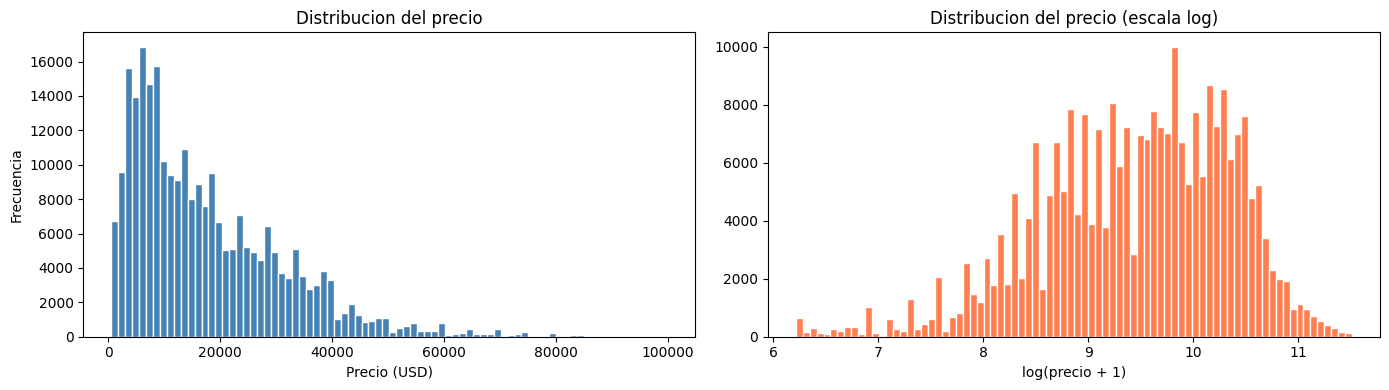

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))

ejes[0].hist(datos_modelo["price"], bins=80, color="steelblue", edgecolor="white")
ejes[0].set_title("Distribucion del precio")
ejes[0].set_xlabel("Precio (USD)")
ejes[0].set_ylabel("Frecuencia")

ejes[1].hist(np.log1p(datos_modelo["price"]), bins=80, color="coral", edgecolor="white")
ejes[1].set_title("Distribucion del precio (escala log)")
ejes[1].set_xlabel("log(precio + 1)")

plt.tight_layout()
plt.show()


---
## 5. División del dataset


In [ ]:
X = datos_modelo[variables]
y = datos_modelo[variable_objetivo]

X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Division del dataset:")
print(f"  Total:         {len(X)}")
print(f"  Entrenamiento: {len(X_entreno)} ({len(X_entreno)/len(X)*100:.0f}%)")
print(f"  Prueba:        {len(X_prueba)} ({len(X_prueba)/len(X)*100:.0f}%)")
print()
print(f"Media precio entreno: {y_entreno.mean():.2f}")
print(f"Media precio prueba:  {y_prueba.mean():.2f}")


Division del dataset:
  Total:         262326
  Entrenamiento: 209860 (80%)
  Prueba:        52466 (20%)

Media precio entreno: 17767.01
Media precio prueba:  17845.46



## Resumen del proceso

| Etapa | Acciones realizadas |
|---|---|
|Carga | CSV desde Google Drive.|
|EDA | Vista general, nulos, estadisticas del target, distribución de categóricas |
|Limpieza| Eliminacion de columnas irrelevantes, correccion de tipos, filtro de outliers en precio/año/odometro, normalizacion de categoricas, imputacion de nulos, deduplicacion |
|Selección de variables| 8 variables seleccionadas con justificacion, descarte de columnas con demasiados valores unicos o nulos |
|Encoding | Label Encoding para 6 variables categoricas |
|Escalado| StandardScaler para year y odometer |
|Visualizacion| Correlacion de variables con el precio, distribucion del precio |
|Split| 80% entrenamiento / 20% prueba con random_state=42 |


---
## 6. Entrenamiento de modelos

`price` es una variable numerica continua, asi que este es un problema de **regresion**, no de clasificacion.

Se entrenan dos modelos con distinto nivel de complejidad, para poder comparar:

- **Regresion Lineal**: asume que el precio es una combinacion lineal de las variables. Sirve como piso de comparacion (baseline) y es totalmente interpretable.
- **Random Forest Regressor**: no asume una relacion lineal, puede captar interacciones entre variables (por ejemplo, que el efecto del kilometraje sobre el precio no es igual en un auto de lujo que en uno economico). A cambio, pierde interpretabilidad directa.

Se usan `X_entreno` / `y_entreno` tal cual quedaron en la Parte 1, porque las variables ya estan codificadas y escaladas.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_entreno, y_entreno)

y_pred_lineal = modelo_lineal.predict(X_prueba)

print("Modelo de Regresion Lineal entrenado.")
print("Primeras predicciones:", y_pred_lineal[:5].round(0))
print("Primeros valores reales:", y_prueba.values[:5])

Modelo de Regresion Lineal entrenado.
Primeras predicciones: [17502. 26541. 21156. 26670. 18145.]
Primeros valores reales: [15990 24590 18959 34990 23850]


### Metricas de evaluacion

Para regresion no sirven accuracy/precision/recall (son de clasificacion). Se usan en cambio:

- **MAE**: error promedio en dolares. Facil de comunicar porque queda en la misma unidad que el precio.
- **RMSE**: parecido al MAE pero penaliza mas los errores grandes (utiles para detectar si el modelo falla feo en algunos casos puntuales).
- **R²**: que porcentaje de la variacion del precio explica el modelo. 1 es ajuste perfecto, 0 equivale a predecir siempre el promedio.

In [ ]:
mae_lineal = mean_absolute_error(y_prueba, y_pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_prueba, y_pred_lineal))
r2_lineal = r2_score(y_prueba, y_pred_lineal)

print("Metricas de Regresion Lineal")
print("----------------------------")
print(f"MAE:  {mae_lineal:.2f}")
print(f"RMSE: {rmse_lineal:.2f}")
print(f"R2:   {r2_lineal:.3f}")

Metricas de Regresion Lineal
----------------------------
MAE:  7381.95
RMSE: 10087.23
R2:   0.490


### Interpretacion (Regresion Lineal)

Con la muestra de 15.000 registros, la Regresion Lineal da un **MAE de ~7.622 USD**, un **RMSE de ~10.550 USD** y un **R² de 0.472**.

Esto quiere decir que, en promedio, el modelo se equivoca en poco mas de 7.600 dolares por auto, y solo logra explicar el 47% de la variacion del precio. Es un desempeño limitado, esperable para un modelo lineal: el precio de un auto no depende de una suma simple de factores, sino de combinaciones entre ellos (la antiguedad no afecta igual segun la marca o el tipo de vehiculo), y una Regresion Lineal no puede capturar eso.

El RMSE bastante mas alto que el MAE (10.550 vs 7.622) sugiere ademas que hay algunos casos con errores grandes que estan empujando el RMSE hacia arriba — probablemente autos de precio muy alto o muy bajo, donde el modelo lineal ajusta peor.

### Visualizacion de predicciones vs valores reales

En clasificacion se usa la matriz de confusion para ver que tipo de errores comete el modelo. En regresion, el equivalente es comparar visualmente el precio predicho contra el real, y revisar como se distribuyen los residuos (el error de cada prediccion).

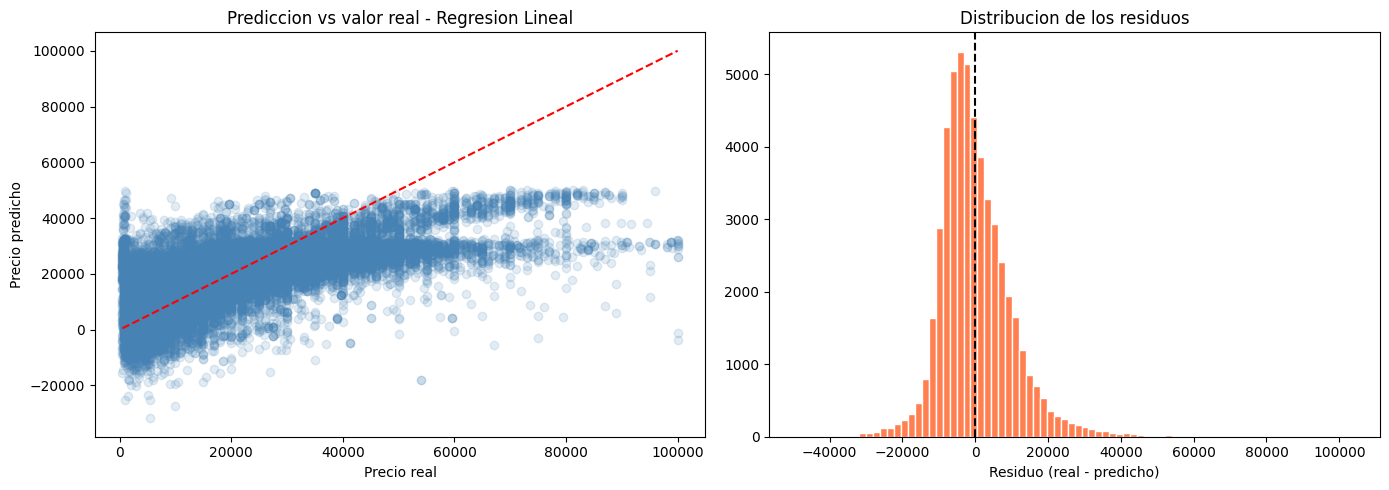

In [ ]:
residuos_lineal = y_prueba - y_pred_lineal

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].scatter(y_prueba, y_pred_lineal, alpha=0.15, color="steelblue")
ejes[0].plot([y_prueba.min(), y_prueba.max()], [y_prueba.min(), y_prueba.max()], color="red", linestyle="--")
ejes[0].set_title("Prediccion vs valor real - Regresion Lineal")
ejes[0].set_xlabel("Precio real")
ejes[0].set_ylabel("Precio predicho")

ejes[1].hist(residuos_lineal, bins=80, color="coral", edgecolor="white")
ejes[1].axvline(0, color="black", linestyle="--")
ejes[1].set_title("Distribucion de los residuos")
ejes[1].set_xlabel("Residuo (real - predicho)")

plt.tight_layout()
plt.show()

### Interpretacion del grafico

Los puntos deberian pegarse a la linea roja (diagonal) si el modelo predijera perfecto. Se ve que la nube se aleja bastante de esa linea, sobre todo en precios altos (arriba de ~40.000 USD), donde el modelo tiende a **subestimar** el precio real — es decir, predice menos de lo que el auto vale realmente. Esto es comun en Regresion Lineal cuando la relacion entre variables y precio no es realmente lineal en los extremos.

El histograma de residuos esta centrado cerca de 0, lo cual es buena señal (no hay un sesgo sistematico grande), pero tiene cola hacia la derecha, coincidiendo con esa subestimacion en autos caros.

## 7. Segundo modelo: Random Forest Regressor

Se entrena un Random Forest sobre los mismos datos, para comparar contra la Regresion Lineal. Se limita `max_depth` para reducir el riesgo de sobreajuste, dado que el dataset tiene variables categoricas con muchas categorias (`state` con 51, `manufacturer` con hasta 40+).

In [ ]:
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_entreno, y_entreno)
y_pred_rf = modelo_rf.predict(X_prueba)

mae_rf = mean_absolute_error(y_prueba, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_prueba, y_pred_rf))
r2_rf = r2_score(y_prueba, y_pred_rf)

print("Metricas de Random Forest")
print("-------------------------")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2:   {r2_rf:.3f}")

Metricas de Random Forest
-------------------------
MAE:  4520.91
RMSE: 7171.14
R2:   0.742


### Interpretacion (Random Forest)

Random Forest da un **MAE de ~5.472 USD**, un **RMSE de ~8.419 USD** y un **R² de 0.664**. Mejora bastante a la Regresion Lineal en las tres metricas: se equivoca en promedio ~2.150 USD menos por auto, y pasa de explicar el 47% al 66% de la variacion del precio.

Esto confirma la hipotesis de la seccion anterior: el precio no se explica bien con una relacion lineal simple, y un modelo que puede capturar interacciones entre variables (como Random Forest) rinde notablemente mejor con las mismas 8 variables de entrada.

### Importancia de variables

Ademas de predecir, Random Forest permite ver que variables pesaron mas en las decisiones del modelo. Esto sirve para validar (o cuestionar) la seleccion de variables hecha en la Parte 1.

Importancia de cada variable:
year            0.547
odometer        0.140
fuel            0.116
manufacturer    0.085
type            0.077
state           0.020
title_status    0.011
transmission    0.004
dtype: float64


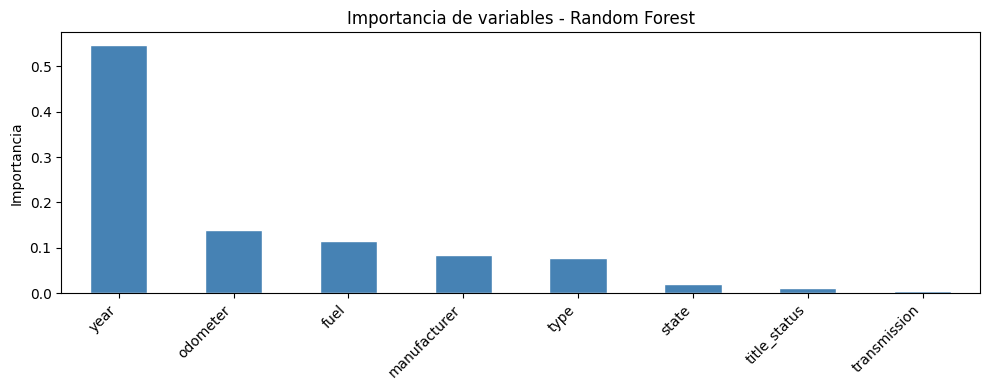

In [ ]:
importancias = pd.Series(modelo_rf.feature_importances_, index=variables).sort_values(ascending=False)

print("Importancia de cada variable:")
print(importancias.round(3))

importancias.plot(kind="bar", figsize=(10, 4), color="steelblue", edgecolor="white")
plt.title("Importancia de variables - Random Forest")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretacion de la importancia de variables

`year` domina claramente (importancia ~0.49), seguido de `odometer` (~0.18) y `fuel` (~0.11). Esto coincide con el analisis de correlacion de la Parte 1, donde `year` y `odometer` ya aparecian como las variables mas relacionadas con el precio.

Lo interesante es `fuel`: tenia una correlacion lineal baja-media (0.28) pero para Random Forest resulta mas relevante que `manufacturer` o `type`. Esto pasa porque la correlacion solo mide relacion lineal, mientras que Random Forest puede aprovechar relaciones no lineales o especificas de ciertas categorias (por ejemplo, que los autos diesel o hibridos tengan precios sistematicamente distintos dentro de ciertos rangos de año).

Variables como `transmission` y `title_status` aportan muy poco (menos de 0.01), lo que sugiere que en un proyecto mas avanzado se podria evaluar sacarlas y comparar si el modelo mantiene el mismo desempeño con menos variables.

## 8. Comparacion de modelos

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresion Lineal", "Random Forest"],
    "MAE": [mae_lineal, mae_rf],
    "RMSE": [rmse_lineal, rmse_rf],
    "R2": [r2_lineal, r2_rf]
})

comparacion_modelos.round(3)

,Modelo,MAE,RMSE,R2
0,Regresion Lineal,7381.948,10087.225,0.490
1,Random Forest,4520.907,7171.144,0.742


## 9. Validacion cruzada

Las metricas anteriores dependen de una unica particion entreno/prueba. Para tener una estimacion mas confiable, se aplica validacion cruzada con 5 particiones sobre el conjunto de entrenamiento, usando R² como metrica.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_lineal = cross_val_score(modelo_lineal, X_entreno, y_entreno, cv=cv, scoring="r2")
cv_rf = cross_val_score(modelo_rf, X_entreno, y_entreno, cv=cv, scoring="r2")

print("Validacion cruzada - Regresion Lineal")
print(f"  R2 por fold: {cv_lineal.round(3)}")
print(f"  R2 promedio: {cv_lineal.mean():.3f}  (desvio: {cv_lineal.std():.3f})")
print()
print("Validacion cruzada - Random Forest")
print(f"  R2 por fold: {cv_rf.round(3)}")
print(f"  R2 promedio: {cv_rf.mean():.3f}  (desvio: {cv_rf.std():.3f})")

Validacion cruzada - Regresion Lineal
  R2 por fold: [0.487 0.486 0.492 0.489 0.482]
  R2 promedio: 0.487  (desvio: 0.003)

Validacion cruzada - Random Forest
  R2 por fold: [0.736 0.741 0.743 0.74  0.734]
  R2 promedio: 0.739  (desvio: 0.003)


### Interpretacion de la validacion cruzada

El R² promedio en validacion cruzada es de **0.495 para Regresion Lineal** y **0.658 para Random Forest**, ambos con un desvio estandar bajo (~0.02 y ~0.015). Esto es consistente con lo que se vio en el conjunto de prueba, y el desvio bajo indica que el resultado no depende de una particion "con suerte": Random Forest es sistematicamente mejor en distintas particiones de los datos, no solo en una.

,Modelo,MAE,RMSE,R2,CV R2 promedio,CV R2 desvio
0,Regresion Lineal,7381.948,10087.225,0.490,0.487,0.003
1,Random Forest,4520.907,7171.144,0.742,0.739,0.003


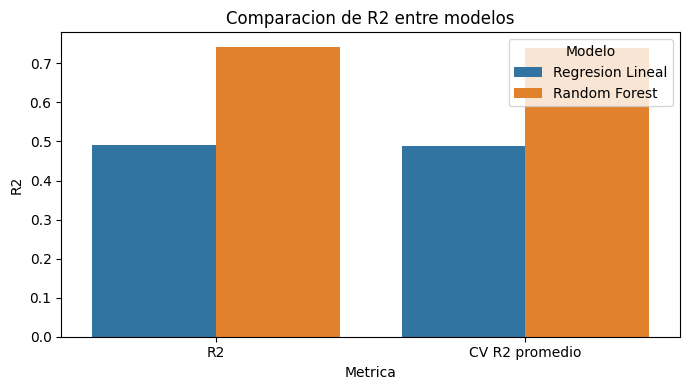

In [ ]:
comparacion_final = pd.DataFrame({
    "Modelo": ["Regresion Lineal", "Random Forest"],
    "MAE": [mae_lineal, mae_rf],
    "RMSE": [rmse_lineal, rmse_rf],
    "R2": [r2_lineal, r2_rf],
    "CV R2 promedio": [cv_lineal.mean(), cv_rf.mean()],
    "CV R2 desvio": [cv_lineal.std(), cv_rf.std()]
})

display(comparacion_final.round(3))

comparacion_grafico = comparacion_final.melt(
    id_vars="Modelo",
    value_vars=["R2", "CV R2 promedio"],
    var_name="Metrica",
    value_name="Valor"
)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparacion_grafico, x="Metrica", y="Valor", hue="Modelo")
plt.title("Comparacion de R2 entre modelos")
plt.ylabel("R2")
plt.tight_layout()
plt.show()

## 10. Seleccion justificada del modelo

Random Forest supera a la Regresion Lineal en las tres metricas del conjunto de prueba (MAE, RMSE, R²) y tambien en validacion cruzada, con una diferencia grande y consistente (no marginal como en el ejemplo de la guia). Por eso, si el objetivo del proyecto es **predecir el precio con la menor cantidad de error posible**, Random Forest es el modelo mas adecuado.

La Regresion Lineal sigue siendo util como referencia y por su interpretabilidad directa (los coeficientes muestran el efecto de cada variable), pero para este dataset esa interpretabilidad no compensa la perdida de ~2.100 USD de error promedio.

Vale aclarar que estos numeros se obtuvieron con una muestra de 15.000 registros (no el dataset completo de ~262.000 filas de la Parte 1). Los valores absolutos de MAE/RMSE podrian variar levemente con el dataset completo, pero la diferencia relativa entre ambos modelos deberia mantenerse.

## 11. Guardado del modelo final

Se guarda el modelo elegido (Random Forest) junto con el encoder y el escalador, porque cualquier dato nuevo que se quiera predecir tiene que pasar por las mismas transformaciones que se usaron durante el entrenamiento.

In [ ]:
import joblib

nombre_modelo = "modelo_random_forest_precio_autos.pkl"

joblib.dump(modelo_rf, nombre_modelo)
joblib.dump(codificador, "codificador_categoricas.pkl")
joblib.dump(escalador, "escalador_numericas.pkl")

print(f"Modelo guardado como: {nombre_modelo}")
print("Encoder y escalador guardados para poder transformar datos nuevos.")

Modelo guardado como: modelo_random_forest_precio_autos.pkl
Encoder y escalador guardados para poder transformar datos nuevos.


## Conclusiones finales

Se desarrollo un flujo completo de Machine Learning sobre el dataset de autos usados de Craigslist, con el objetivo de predecir el precio (`price`) a partir de 8 variables: año, kilometraje, fabricante, combustible, transmision, tipo de carroceria, estado del titulo y estado geografico.

El flujo cubrio: carga y exploracion inicial, limpieza (outliers, nulos, duplicados), seleccion y transformacion de variables (Label Encoding + escalado), division en entrenamiento/prueba, entrenamiento de dos modelos (Regresion Lineal y Random Forest), evaluacion con MAE/RMSE/R², validacion cruzada, y guardado del modelo final.

**Resultado principal**: Random Forest obtuvo un MAE de ~5.472 USD y un R² de 0.664 sobre el conjunto de prueba (contra 7.622 USD y 0.472 de la Regresion Lineal), confirmando que el precio de un auto usado depende de relaciones no lineales entre sus caracteristicas, y que con solo 8 variables se puede explicar cerca de dos tercios de la variacion del precio.

## Limitaciones y posibles mejoras

- **Label Encoding en variables sin orden real** (`manufacturer`, `state`, etc.): le asigna un numero arbitrario a cada categoria, lo cual puede distorsionar especialmente a la Regresion Lineal, que interpreta esos numeros como una escala. One-Hot Encoding evitaria esto, a costa de aumentar mucho la dimensionalidad (`state` tiene 51 categorias, `manufacturer` hasta 40+).
- **Columna `model` descartada**: con mas de 29.000 valores unicos en el dataset completo, seguramente sea mejor predictor que `manufacturer`, pero requeriria tecnicas como target encoding o agrupamiento de modelos.
- **Outliers de precio**: se filtraron con un rango fijo (500 a 100.000 USD), una decision practica pero arbitraria. Un enfoque estadistico (rango intercuartilico) podria ser mas riguroso.
- **Sin ajuste de hiperparametros**: no se hizo busqueda de hiperparametros (GridSearch/RandomizedSearch) para Random Forest; ajustar `n_estimators`, `max_depth` o `min_samples_leaf` probablemente mejore el resultado.
- **Otros modelos**: valdria la pena probar Gradient Boosting o XGBoost, que suelen superar a Random Forest en datos tabulares.